# Post-Training Analysis
Generates ALL remaining figures and numbers for the paper:
1. Per-patient AUC heatmap (all 5 models)
2. FAR-Sensitivity trade-off curves (all 5 models)
3. Parameter counts

**All model classes are embedded — no manual pasting needed.**

Run this AFTER all 5 models have completed training.

In [2]:
import os, sys, json, time, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sys.path.insert(0, 'D:/Code')
from data_utils import make_patient_splits, SEEDS, DATA_DIR

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FS = 256
N_CHANNELS = 18
WIN = 20 * FS  # 5120
RESULTS_ROOT = r'D:\seizure_results'
FIG_DIR = os.path.join(RESULTS_ROOT, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Device: {DEVICE}')
print(f'Figure output: {FIG_DIR}')

Device: cuda
Figure output: D:\seizure_results\figures


## 1. Model Class Definitions
All four DL model classes are defined below, matching the training notebooks exactly.

In [3]:
# ══════════════════════════════════════════════════════════════════════
# 1D-CNN (MultiScaleBlock + CNN1D)
# ══════════════════════════════════════════════════════════════════════

class MultiScaleBlock(nn.Module):
    """Parallel 1-D convolutions with three kernel sizes, concatenated."""
    def __init__(self, in_ch, out_ch, kernels=(3, 5, 7)):
        super().__init__()
        assert out_ch % len(kernels) == 0
        branch_ch = out_ch // len(kernels)
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_ch, branch_ch, k, padding=k // 2, bias=False),
                nn.BatchNorm1d(branch_ch),
                nn.GELU(),
            )
            for k in kernels
        ])

    def forward(self, x):
        return torch.cat([b(x) for b in self.branches], dim=1)


class CNN1D(nn.Module):
    """Three-stage 1-D CNN. Input: (B, 18, 5120), Output: (B, 2)"""
    def __init__(self, n_channels=N_CHANNELS, dropout=0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            MultiScaleBlock(n_channels, 96),
            nn.MaxPool1d(4),
            nn.Dropout(dropout * 0.5),
            MultiScaleBlock(96, 192),
            nn.MaxPool1d(4),
            nn.Dropout(dropout * 0.5),
            MultiScaleBlock(192, 384),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(384, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))


print('1D-CNN defined.')

1D-CNN defined.


In [4]:
# ══════════════════════════════════════════════════════════════════════
# EEGNet (Lawhern et al. 2018)
# kern_length=127 (odd) to avoid T+1 artefact with symmetric padding
# ══════════════════════════════════════════════════════════════════════

class EEGNet(nn.Module):
    """EEGNet. Input: (B, 18, 5120), Output: (B, 2)"""
    def __init__(self,
                 n_channels   = N_CHANNELS,
                 n_times      = WIN,
                 F1           = 8,
                 D            = 2,
                 kern_length  = 127,
                 dropout      = 0.5,
                 n_classes    = 2):
        super().__init__()
        F2 = F1 * D

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kern_length),
                      padding=(0, kern_length // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(F2, F2, kernel_size=(1, 15),
                      padding=(0, 7), groups=F2, bias=False),
            nn.Conv2d(F2, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            flat  = self.block2(self.block1(dummy)).view(1, -1).shape[1]

        self.classifier = nn.Linear(flat, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


print('EEGNet defined.')

EEGNet defined.


In [5]:
# ══════════════════════════════════════════════════════════════════════
# TCN (Bai et al. 2018)
# ══════════════════════════════════════════════════════════════════════

class TemporalBlock(nn.Module):
    """Single TCN residual block with dilated causal convolutions."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.utils.weight_norm(nn.Conv1d(
            in_ch, out_ch, kernel_size, dilation=dilation, padding=padding))
        self.conv2 = nn.utils.weight_norm(nn.Conv1d(
            out_ch, out_ch, kernel_size, dilation=dilation, padding=padding))

        nn.init.normal_(self.conv1.weight_v, 0, 0.01)
        nn.init.ones_(self.conv1.weight_g)
        nn.init.normal_(self.conv2.weight_v, 0, 0.01)
        nn.init.ones_(self.conv2.weight_g)

        self.net = nn.Sequential(
            self.conv1, nn.ReLU(), nn.Dropout(dropout),
            self.conv2, nn.ReLU(), nn.Dropout(dropout),
        )
        self.residual = (
            nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        out = out[:, :, :x.size(2)]  # causal trim
        return self.relu(out + self.residual(x))


class TCN(nn.Module):
    """Temporal Convolutional Network. Input: (B, 18, 5120), Output: (B, 2)"""
    def __init__(self,
                 n_channels  = N_CHANNELS,
                 n_filters   = 64,
                 kernel_size = 8,
                 dilations   = (1, 2, 4, 8),
                 dropout     = 0.2,
                 n_classes   = 2):
        super().__init__()
        layers = []
        in_ch  = n_channels
        for d in dilations:
            layers.append(TemporalBlock(in_ch, n_filters, kernel_size, d, dropout))
            in_ch = n_filters
        self.tcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_filters, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.tcn(x)))


print('TCN defined.')

TCN defined.


In [6]:
# ══════════════════════════════════════════════════════════════════════
# EEG-Conformer (Song et al. 2023)
# ══════════════════════════════════════════════════════════════════════

class PatchEmbedding(nn.Module):
    """(B, C, T) -> (B, S, D) token sequence."""
    def __init__(self, n_channels=N_CHANNELS, emb_size=40, kern_t=15,
                 pool_size=75, pool_stride=75, dropout=0.5):
        super().__init__()
        self.temporal_conv = nn.Sequential(
            nn.Conv2d(1, emb_size, kernel_size=(1, kern_t),
                      padding=(0, kern_t // 2), bias=False),
            nn.BatchNorm2d(emb_size),
        )
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(emb_size, emb_size, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(emb_size),
            nn.ELU(),
            nn.Dropout(dropout),
        )
        self.pool = nn.AvgPool2d(kernel_size=(1, pool_size),
                                 stride=(1, pool_stride))

    def forward(self, x):
        x = x.unsqueeze(1)            # (B, 1, C, T)
        x = self.temporal_conv(x)     # (B, D, C, T)
        x = self.spatial_conv(x)      # (B, D, 1, T)
        x = self.pool(x)              # (B, D, 1, S)
        x = x.squeeze(2)              # (B, D, S)
        x = x.permute(0, 2, 1)       # (B, S, D)
        return x


class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size, num_heads, dropout=0.5):
        super().__init__()
        self.attn = nn.MultiheadAttention(emb_size, num_heads,
                                          dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.attn(x, x, x)
        return self.dropout(out)


class FeedForward(nn.Module):
    def __init__(self, emb_size, expansion=4, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_size, emb_size * expansion),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_size * expansion, emb_size),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_size, num_heads, dropout=0.5):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_size)
        self.attn  = MultiHeadAttention(emb_size, num_heads, dropout)
        self.norm2 = nn.LayerNorm(emb_size)
        self.ff    = FeedForward(emb_size, dropout=dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, depth, emb_size, num_heads, dropout=0.5):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(emb_size, num_heads, dropout)
            for _ in range(depth)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class ClassificationHead(nn.Module):
    def __init__(self, emb_size, n_tokens, n_classes=2, dropout=0.5):
        super().__init__()
        flat_dim = emb_size * n_tokens
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 256),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 32),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class EEGConformer(nn.Module):
    """EEG-Conformer. Input: (B, 18, 5120), Output: (B, 2)"""
    def __init__(self, n_channels=N_CHANNELS, n_times=WIN, emb_size=40,
                 depth=6, num_heads=10, kern_t=15, pool_size=75,
                 pool_stride=75, dropout=0.5, n_classes=2):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            n_channels, emb_size, kern_t, pool_size, pool_stride, dropout)
        with torch.no_grad():
            dummy = torch.zeros(1, n_channels, n_times)
            tokens = self.patch_embed(dummy)
            n_tokens = tokens.shape[1]
        self.transformer = TransformerEncoder(depth, emb_size, num_heads, dropout)
        self.classifier  = ClassificationHead(emb_size, n_tokens, n_classes, dropout)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.transformer(x)
        return self.classifier(x)


print('EEG-Conformer defined.')

EEG-Conformer defined.


In [7]:
# ══════════════════════════════════════════════════════════════════════
# Parameter counts
# ══════════════════════════════════════════════════════════════════════

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_for_count = {
    '1D-CNN':        CNN1D(),
    'EEGNet':        EEGNet(),
    'TCN':           TCN(),
    'EEG-Conformer': EEGConformer(),
}

print('\n=== Parameter Counts ===')
param_counts = {}
for name, m in models_for_count.items():
    n_params = count_parameters(m)
    param_counts[name] = n_params
    print(f'  {name:20s}: {n_params:>10,}')

# Relative size (normalized to smallest DL model)
min_params = min(param_counts.values())
print('\n=== Relative Size (vs smallest DL model) ===')
for name, n in param_counts.items():
    print(f'  {name:20s}: {n/min_params:.1f}x')


=== Parameter Counts ===
  1D-CNN              :    520,322
  EEGNet              :      7,002
  TCN                 :    245,122
  EEG-Conformer       :    852,746

=== Relative Size (vs smallest DL model) ===
  1D-CNN              : 74.3x
  EEGNet              : 1.0x
  TCN                 : 35.0x
  EEG-Conformer       : 121.8x


c:\Users\11217\anaconda3\envs\seizure_prediction\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


## 2. Helper Functions

In [8]:
def load_patient_raw(pt, data_dir=DATA_DIR):
    """Load a single patient's data."""
    X = np.load(os.path.join(data_dir, f"{pt}_X.npy"), mmap_mode='r')
    y = np.load(os.path.join(data_dir, f"{pt}_y.npy"))
    return X, y


def predict_dl(model, X, batch_size=256):
    """Run inference with a PyTorch model, return probabilities."""
    model.eval()
    model.to(DEVICE)
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.tensor(
                np.array(X[i:i+batch_size]), dtype=torch.float32
            ).to(DEVICE)
            logits = model(batch)
            p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            probs.append(p)
    return np.concatenate(probs)


BANDS = [(0.5, 4), (4, 8), (8, 13), (13, 30), (30, 40)]

def extract_psd(X, batch_size=500):
    """Extract PSD band-power features in batches to avoid OOM."""
    all_feats = []
    for i in range(0, len(X), batch_size):
        chunk = np.array(X[i:i+batch_size])  # only load a small chunk
        freqs, pxx = welch(chunk, fs=FS, axis=-1, nperseg=512)
        feats = []
        for lo, hi in BANDS:
            mask = (freqs >= lo) & (freqs <= hi)
            feats.append(pxx[:, :, mask].mean(axis=-1))
        all_feats.append(np.concatenate(feats, axis=1))
    return np.concatenate(all_feats, axis=0)


print('Helper functions defined.')

Helper functions defined.


## 3. Per-Patient AUC Computation (All 5 Models × 20 Seeds)

In [11]:
model_names = ['PSD+LDA', '1D-CNN', 'EEGNet', 'TCN', 'EEG-Conformer']

checkpoint_dirs = {
    '1D-CNN':        os.path.join(RESULTS_ROOT, '1dcnn'),
    'EEGNet':        os.path.join(RESULTS_ROOT, 'eegnet'),
    'TCN':           os.path.join(RESULTS_ROOT, 'tcn'),
    'EEG-Conformer': os.path.join(RESULTS_ROOT, 'eeg_conformer'),
}

model_classes = {
    '1D-CNN':        CNN1D,
    'EEGNet':        EEGNet,
    'TCN':           TCN,
    'EEG-Conformer': EEGConformer,
}

# Storage: {model: {seed: {patient: auc}}}
all_per_patient = {m: {} for m in model_names}
# Storage for predictions (needed for FAR curves): {model: {seed: {patient: (probs, labels)}}}
all_predictions = {m: {} for m in model_names}

In [12]:
for seed in SEEDS:
    print(f'\n{"="*60}')
    print(f'--- Seed {seed} ---')
    print(f'{"="*60}')
    train_pts, val_pts, test_pts = make_patient_splits(seed)
    print(f'  Test patients: {test_pts}')

    # ── PSD+LDA: train fresh (fast) ──
    X_tr_list, y_tr_list = [], []
    for pt in train_pts:
        X_raw, y = load_patient_raw(pt)
        X_tr_list.append(extract_psd(X_raw))
        y_tr_list.append(y)
    X_train_psd = np.concatenate(X_tr_list)
    y_train = np.concatenate(y_tr_list)

    lda = LinearDiscriminantAnalysis(priors=[0.5, 0.5])
    lda.fit(X_train_psd, y_train)

    all_per_patient['PSD+LDA'][seed] = {}
    all_predictions['PSD+LDA'][seed] = {}
    for pt in test_pts:
        X_raw, y = load_patient_raw(pt)
        X_psd = extract_psd(np.array(X_raw))
        probs = lda.predict_proba(X_psd)[:, 1]
        if len(np.unique(y)) >= 2:
            auc = roc_auc_score(y, probs)
        else:
            auc = np.nan
        all_per_patient['PSD+LDA'][seed][pt] = auc
        all_predictions['PSD+LDA'][seed][pt] = (probs, y)
        print(f'  {pt}: PSD={auc:.3f}')

    # ── DL models: load best checkpoint ──
    for mname in ['1D-CNN', 'EEGNet', 'TCN', 'EEG-Conformer']:
        ckpt_path = os.path.join(checkpoint_dirs[mname], f'seed{seed}_best.pt')
        if not os.path.exists(ckpt_path):
            print(f'  [SKIP] {mname} seed {seed}: checkpoint not found at {ckpt_path}')
            all_per_patient[mname][seed] = {}
            all_predictions[mname][seed] = {}
            continue

        model = model_classes[mname]()
        state = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(state)
        model.to(DEVICE)
        model.eval()

        all_per_patient[mname][seed] = {}
        all_predictions[mname][seed] = {}
        for pt in test_pts:
            X_raw, y = load_patient_raw(pt)
            probs = predict_dl(model, X_raw)
            if len(np.unique(y)) >= 2:
                auc = roc_auc_score(y, probs)
            else:
                auc = np.nan
            all_per_patient[mname][seed][pt] = auc
            all_predictions[mname][seed][pt] = (probs, y)
            print(f'  {pt}: {mname}={auc:.3f}')

        # Free GPU memory
        del model
        torch.cuda.empty_cache()

print('\nPer-patient computation complete.')


--- Seed 42 ---
  Test patients: ['chb17', 'chb16', 'chb03', 'chb15']
  chb17: PSD=0.627
  chb16: PSD=0.736
  chb03: PSD=0.472
  chb15: PSD=0.500
  chb17: 1D-CNN=0.697
  chb16: 1D-CNN=0.864
  chb03: 1D-CNN=0.401
  chb15: 1D-CNN=0.605
  chb17: EEGNet=0.605
  chb16: EEGNet=0.565
  chb03: EEGNet=0.394
  chb15: EEGNet=0.611


c:\Users\11217\anaconda3\envs\seizure_prediction\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  chb17: TCN=0.311
  chb16: TCN=0.760
  chb03: TCN=0.473
  chb15: TCN=0.594
  chb17: EEG-Conformer=0.523
  chb16: EEG-Conformer=0.644
  chb03: EEG-Conformer=0.484
  chb15: EEG-Conformer=0.509

--- Seed 123 ---
  Test patients: ['chb08', 'chb18', 'chb11', 'chb07']
  chb08: PSD=0.636
  chb18: PSD=0.405
  chb11: PSD=0.548
  chb07: PSD=0.451
  chb08: 1D-CNN=0.699
  chb18: 1D-CNN=0.256
  chb11: 1D-CNN=0.416
  chb07: 1D-CNN=0.583
  chb08: EEGNet=0.594
  chb18: EEGNet=0.656
  chb11: EEGNet=0.500
  chb07: EEGNet=0.542


c:\Users\11217\anaconda3\envs\seizure_prediction\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  chb08: TCN=0.754
  chb18: TCN=0.510
  chb11: TCN=0.452
  chb07: TCN=0.581
  chb08: EEG-Conformer=0.635
  chb18: EEG-Conformer=0.601
  chb11: EEG-Conformer=0.485
  chb07: EEG-Conformer=0.295

--- Seed 456 ---
  Test patients: ['chb09', 'chb18', 'chb03', 'chb10']
  chb09: PSD=0.525
  chb18: PSD=0.455
  chb03: PSD=0.545
  chb10: PSD=0.690
  chb09: 1D-CNN=0.600
  chb18: 1D-CNN=0.304
  chb03: 1D-CNN=0.329
  chb10: 1D-CNN=0.593
  chb09: EEGNet=0.599
  chb18: EEGNet=0.583
  chb03: EEGNet=0.370
  chb10: EEGNet=0.592


...

  chb11: TCN=0.520
  chb09: TCN=0.700
  chb06: TCN=0.484
  chb17: TCN=0.358
  chb11: EEG-Conformer=0.638
  chb09: EEG-Conformer=0.553
  chb06: EEG-Conformer=0.515
  chb17: EEG-Conformer=0.596

--- Seed 15926 ---
  Test patients: ['chb16', 'chb22', 'chb07', 'chb03']
  chb16: PSD=0.680
  chb22: PSD=0.512
  chb07: PSD=0.392
  chb03: PSD=0.416
  chb16: 1D-CNN=0.675
  chb22: 1D-CNN=0.710
  chb07: 1D-CNN=0.491
  chb03: 1D-CNN=0.498
  chb16: EEGNet=0.620
  chb22: EEGNet=0.670
  chb07: EEGNet=0.547
  chb03: EEGNet=0.384


c:\Users\11217\anaconda3\envs\seizure_prediction\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  chb16: TCN=0.645
  chb22: TCN=0.732
  chb07: TCN=0.568
  chb03: TCN=0.412
  chb16: EEG-Conformer=0.653
  chb22: EEG-Conformer=0.677
  chb07: EEG-Conformer=0.409
  chb03: EEG-Conformer=0.360

--- Seed 16384 ---
  Test patients: ['chb18', 'chb15', 'chb13', 'chb11']
  chb18: PSD=0.365
  chb15: PSD=0.435
  chb13: PSD=0.629
  chb11: PSD=0.399
  chb18: 1D-CNN=0.430
  chb15: 1D-CNN=0.470
  chb13: 1D-CNN=0.654
  chb11: 1D-CNN=0.492
  chb18: EEGNet=0.708
  chb15: EEGNet=0.547
  chb13: EEGNet=0.422
  chb11: EEGNet=0.487


c:\Users\11217\anaconda3\envs\seizure_prediction\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  chb18: TCN=0.631
  chb15: TCN=0.531
  chb13: TCN=0.570
  chb11: TCN=0.445
  chb18: EEG-Conformer=0.365
  chb15: EEG-Conformer=0.433
  chb13: EEG-Conformer=0.642
  chb11: EEG-Conformer=0.466

Per-patient computation complete.


## 4. Per-Patient AUC Heatmap

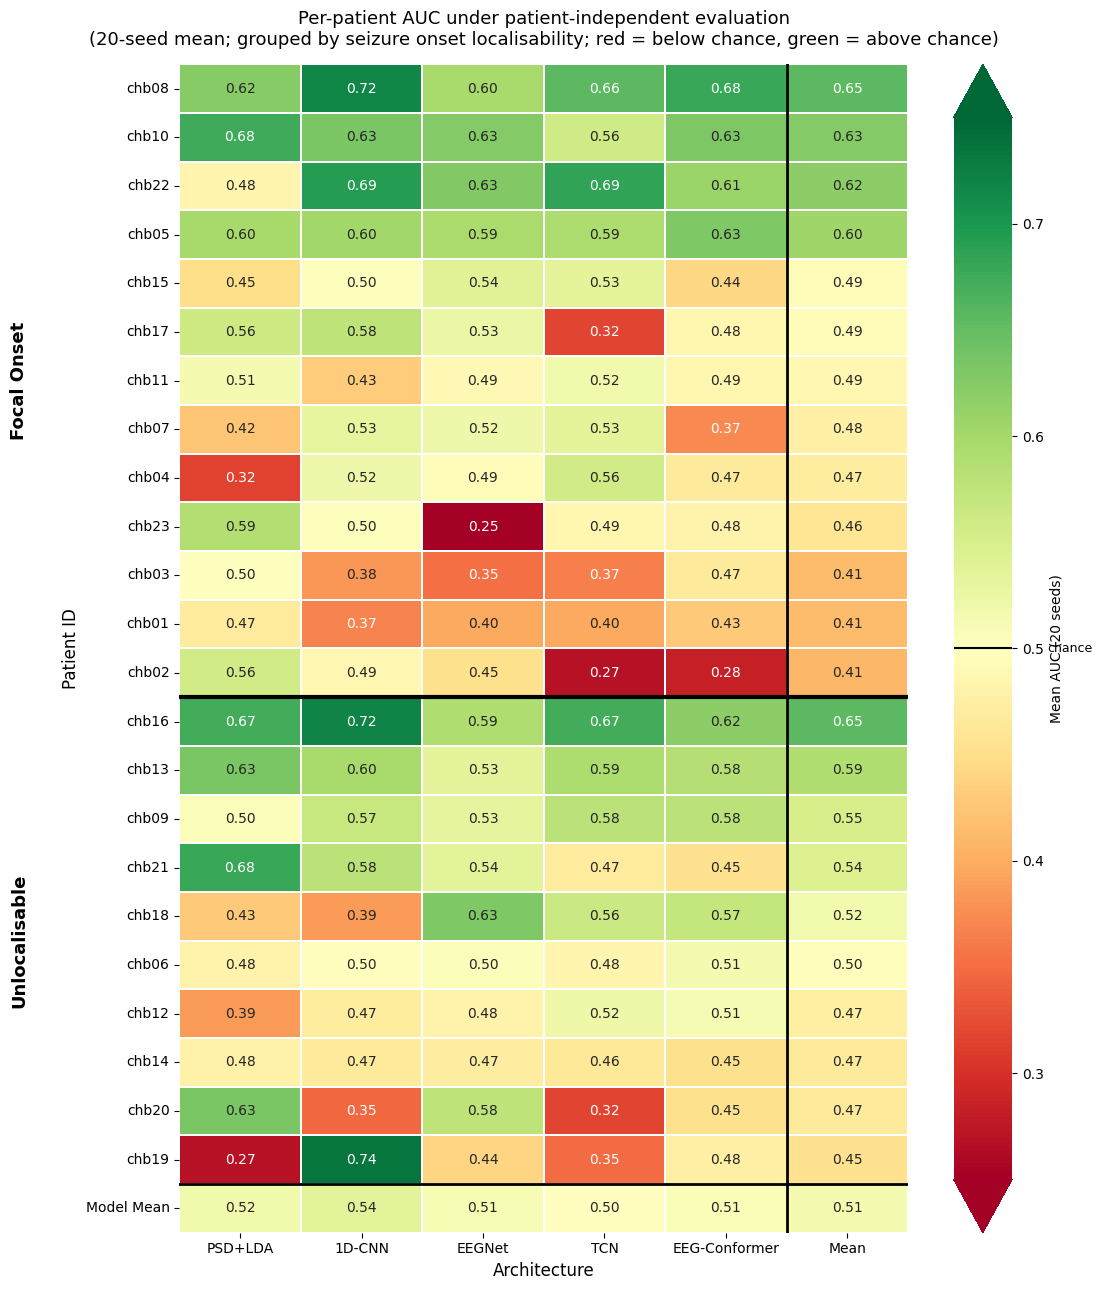

Groups: 13 focal / 10 unlocalisable
Grand mean AUC across all cells: 0.514
Per-model mean (across 23 patients):
  PSD+LDA        : 0.518
  1D-CNN         : 0.535
  EEGNet         : 0.511
  TCN            : 0.499
  EEG-Conformer  : 0.508


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

onset_groups = {
    'chb01': 'Focal',         'chb02': 'Focal',         'chb03': 'Focal',
    'chb04': 'Focal',         'chb05': 'Focal',         'chb06': 'Unlocalisable',
    'chb07': 'Focal',         'chb08': 'Focal',         'chb09': 'Unlocalisable',
    'chb10': 'Focal',         'chb11': 'Focal',         'chb12': 'Unlocalisable',
    'chb13': 'Unlocalisable', 'chb14': 'Unlocalisable', 'chb15': 'Focal',
    'chb16': 'Unlocalisable', 'chb17': 'Focal',         'chb18': 'Unlocalisable',
    'chb19': 'Unlocalisable', 'chb20': 'Unlocalisable', 'chb21': 'Unlocalisable',
    'chb22': 'Focal',         'chb23': 'Focal',
}

all_patients = sorted(onset_groups.keys())
n_patients = len(all_patients)
n_models = len(model_names)

heatmap = np.full((n_patients, n_models), np.nan)
for j, m in enumerate(model_names):
    for i, pt in enumerate(all_patients):
        vals = [all_per_patient[m][s].get(pt, np.nan) for s in SEEDS]
        vals = [v for v in vals if not np.isnan(v)]
        if vals:
            heatmap[i, j] = np.mean(vals)


mean_per_patient = np.nanmean(heatmap, axis=1)

focal_entries, unloc_entries = [], []
for i, pt in enumerate(all_patients):
    entry = {'idx': i, 'pt': pt, 'mean_auc': mean_per_patient[i]}
    (focal_entries if onset_groups[pt] == 'Focal' else unloc_entries).append(entry)

focal_entries.sort(key=lambda x: x['mean_auc'], reverse=True)
unloc_entries.sort(key=lambda x: x['mean_auc'], reverse=True)

combined = focal_entries + unloc_entries
sort_idx         = [e['idx'] for e in combined]
patients_sorted  = [e['pt']  for e in combined]
heatmap_sorted   = heatmap[sort_idx]


patient_means   = np.nanmean(heatmap_sorted, axis=1, keepdims=True)
model_means     = np.nanmean(heatmap_sorted, axis=0, keepdims=True)
grand_mean      = np.array([[np.nanmean(heatmap_sorted)]])

full_matrix = np.vstack([
    np.hstack([heatmap_sorted, patient_means]),
    np.hstack([model_means,    grand_mean   ]),
])

xticklabels = list(model_names) + ['Mean']
yticklabels = patients_sorted    + ['Model Mean']


norm = mcolors.TwoSlopeNorm(vmin=0.25, vcenter=0.50, vmax=0.75)
cmap = plt.get_cmap('RdYlGn').copy()
cmap.set_bad('lightgrey')

fig, ax = plt.subplots(figsize=(11, 13))

sns.heatmap(
    full_matrix,
    annot=True, fmt='.2f',
    cmap=cmap, norm=norm,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Mean AUC (20 seeds)', 'extend': 'both'},
    ax=ax,
)


cbar = ax.collections[0].colorbar
cbar.ax.axhline(0.50, color='black', lw=1.5)
cbar.ax.text(
    1.6, 0.50, 'chance',
    transform=cbar.ax.get_yaxis_transform(),
    va='center', ha='left', fontsize=9,
)

split_line = len(focal_entries)
ax.axhline(split_line, color='black', lw=3)        # Focal / Unlocalisable
ax.axhline(n_patients, color='black', lw=2)        # main block / Model Mean
ax.axvline(n_models,   color='black', lw=2)        # main block / Mean column


total_plot_rows = n_patients + 1

focal_centre_ax = 1.0 - split_line / (2 * total_plot_rows)
unloc_centre_ax = 1.0 - (split_line + n_patients) / (2 * total_plot_rows)

ax.text(-0.22, focal_centre_ax, 'Focal Onset',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        rotation=90, va='center', ha='center')
ax.text(-0.22, unloc_centre_ax, 'Unlocalisable',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        rotation=90, va='center', ha='center')


ax.set_title(
    'Per-patient AUC under patient-independent evaluation\n'
    '(20-seed mean; grouped by seizure onset localisability; '
    'red = below chance, green = above chance)',
    fontsize=13, pad=14,
)
ax.set_xlabel('Architecture', fontsize=12)
ax.set_ylabel('Patient ID', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'Figure_2_Heatmap_Grouped.pdf'),
            dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'Figure_2_Heatmap_Grouped.png'),
            dpi=300, bbox_inches='tight')
plt.show()


print(f"Groups: {len(focal_entries)} focal / {len(unloc_entries)} unlocalisable")
print(f"Grand mean AUC across all cells: {grand_mean[0, 0]:.3f}")
print("Per-model mean (across 23 patients):")
for m, mm in zip(model_names, model_means.flatten()):
    print(f"  {m:15s}: {mm:.3f}")

## 4b. Per-Patient Sensitivity & FAR 

In [14]:
# ── Per-Patient Sensitivity & FAR ──────────────────────────────────────────
# Produces a per-patient table (AUC / Sensitivity / FAR) for all 5 models,
# averaged over SEEDS. Saves to seizure_results/per_patient_metrics.csv.
import csv as _csv
from sklearn.metrics import roc_auc_score

# ── Step 1: load Youden thresholds for all models from results.json ──
RESULT_FILES = {
    '1D-CNN':        os.path.join(RESULTS_ROOT, '1dcnn',        'results.json'),
    'EEGNet':        os.path.join(RESULTS_ROOT, 'eegnet',       'results.json'),
    'TCN':           os.path.join(RESULTS_ROOT, 'tcn',          'results.json'),
    'EEG-Conformer': os.path.join(RESULTS_ROOT, 'eeg_conformer','results.json'),
    'PSD+LDA':       os.path.join(RESULTS_ROOT, 'psd_lda',      'results.json'),
}

thresholds = {m: {} for m in model_names}  # {model: {seed: float}}

for mname, path in RESULT_FILES.items():
    if os.path.exists(path):
        with open(path) as f:
            _rs = json.load(f)
        for r in _rs:
            thresholds[mname][r['seed']] = r['threshold']
        if mname == 'PSD+LDA':
            print(f"PSD+LDA thresholds loaded from results.json ({len(_rs)} seeds)")
    elif mname == 'PSD+LDA':
        print("WARNING: psd_lda/results.json not found, falling back to 0.5")
        for seed in SEEDS:
            thresholds['PSD+LDA'][seed] = 0.5

# ── Step 2: compute per-patient AUC / Sensitivity / FAR (seed-averaged) ──
per_pt_metrics = {m: {} for m in model_names}

for mname in model_names:
    all_pts = sorted(set(
        pt for sd in all_predictions[mname].values() for pt in sd
    ))
    for pt in all_pts:
        aucs, sens, fars = [], [], []
        for seed in SEEDS:
            sd = all_predictions[mname].get(seed, {})
            if pt not in sd:
                continue
            probs, y = sd[pt]
            thr    = thresholds[mname].get(seed, 0.5)
            y_pred = (probs >= thr).astype(int)

            if len(np.unique(y)) >= 2:
                aucs.append(roc_auc_score(y, probs))

            tp = int(((y_pred == 1) & (y == 1)).sum())
            fn = int(((y_pred == 0) & (y == 1)).sum())
            if (tp + fn) > 0:
                sens.append(tp / (tp + fn))

            n_inter = int((y == 0).sum())
            n_fp    = int(((y_pred == 1) & (y == 0)).sum())
            if n_inter > 0:
                fars.append(n_fp / (n_inter * 300 / 3600))

        per_pt_metrics[mname][pt] = {
            'auc': np.mean(aucs) if aucs else np.nan,
            'sen': np.mean(sens) if sens else np.nan,
            'far': np.mean(fars) if fars else np.nan,
        }

# ── Step 3: print table ──
all_pts_sorted = sorted(set(
    pt for m in model_names for pt in per_pt_metrics[m]
))

col_w = 7
header = f"{'Patient':8s}"
for m in model_names:
    short = m[:7]
    header += f"  {short:>{col_w}}AUC  {short:>{col_w}}Sen  {short:>{col_w}}FAR"
print(header)
print('-' * len(header))
for pt in all_pts_sorted:
    row = f"{pt:8s}"
    for m in model_names:
        d = per_pt_metrics[m].get(pt, {'auc': float('nan'), 'sen': float('nan'), 'far': float('nan')})
        auc = f"{d['auc']:.3f}" if not np.isnan(d['auc']) else '  nan'
        sen = f"{d['sen']:.3f}" if not np.isnan(d['sen']) else '  nan'
        far = f"{d['far']:.2f}"  if not np.isnan(d['far']) else '  nan'
        row += f"  {auc:>10}  {sen:>10}  {far:>10}"
    print(row)

# ── Step 4: save CSV ──
csv_path = os.path.join(RESULTS_ROOT, 'per_patient_metrics.csv')
fieldnames = ['patient']
for m in model_names:
    fieldnames += [f'{m}_auc', f'{m}_sen', f'{m}_far']

with open(csv_path, 'w', newline='') as f:
    w = _csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    for pt in all_pts_sorted:
        row = {'patient': pt}
        for m in model_names:
            d = per_pt_metrics[m].get(pt, {})
            row[f'{m}_auc'] = round(d.get('auc', float('nan')), 4) if not np.isnan(d.get('auc', float('nan'))) else ''
            row[f'{m}_sen'] = round(d.get('sen', float('nan')), 4) if not np.isnan(d.get('sen', float('nan'))) else ''
            row[f'{m}_far'] = round(d.get('far', float('nan')), 4) if not np.isnan(d.get('far', float('nan'))) else ''
        w.writerow(row)

print(f'CSV saved to {csv_path}')

PSD+LDA thresholds loaded from results.json (20 seeds)
Patient   PSD+LDAAUC  PSD+LDASen  PSD+LDAFAR   1D-CNNAUC   1D-CNNSen   1D-CNNFAR   EEGNetAUC   EEGNetSen   EEGNetFAR      TCNAUC      TCNSen      TCNFAR  EEG-ConAUC  EEG-ConSen  EEG-ConFAR
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
chb01          0.468       0.182        3.46       0.368       0.290        4.79       0.398       0.392        6.26       0.397       0.369        5.66       0.429       0.345        4.90
chb02          0.557       0.574        5.51       0.487       0.034        1.51       0.451       0.297        4.67       0.269       0.000        0.04       0.285       0.000        0.07
chb03          0.500       0.314        4.31       0.381       0.041        2.48       0.353       0.216        5.00       0.365       0.096        3.60       0.466       0.338        4.14


## 5. FAR-Sensitivity Trade-off Curves

In [12]:
def compute_far_sensitivity(predictions_dict, seeds, patients=None, thresholds=np.arange(0, 1.01, 0.01)):
    """
    计算模型在不同阈值下的平均 FAR 和 Sensitivity。
    """
    mean_fars = []
    mean_sens = []
    std_fars = []
    std_sens = []

    for thr in thresholds:
        seed_fars = []
        seed_sens = []
        
        for seed in seeds:
            if seed not in predictions_dict:
                continue
            
            # 聚合当前 Seed 下所有患者的结果
            all_y_true = []
            all_y_pred_probs = []
            
            target_pts = patients if patients is not None else predictions_dict[seed].keys()
            
            current_seed_fps = 0
            current_seed_total_inter_hours = 0
            current_seed_tps = 0
            current_seed_positives = 0

            for pt in target_pts:
                if pt not in predictions_dict[seed]:
                    continue
                probs, y = predictions_dict[seed][pt]
                y_pred = (probs >= thr).astype(int)

                # 计算 Sensitivity 相关的组件
                current_seed_tps += ((y_pred == 1) & (y == 1)).sum()
                current_seed_positives += (y == 1).sum()

                # 计算 FAR 相关的组件 (假设每 300 个样本是 1 小时，或者根据你之前的 300/3600 逻辑)
                # 这里保持跟你之前的 CSV 计算逻辑一致
                current_seed_fps += ((y_pred == 1) & (y == 0)).sum()
                current_seed_total_inter_hours += (y == 0).sum() * (300 / 3600)

            # 计算该 Seed 的指标
            s = current_seed_tps / current_seed_positives if current_seed_positives > 0 else np.nan
            f = current_seed_fps / current_seed_total_inter_hours if current_seed_total_inter_hours > 0 else np.nan
            
            if not np.isnan(s): seed_sens.append(s)
            if not np.isnan(f): seed_fars.append(f)

        # 跨 Seed 计算均值和标准差
        mean_sens.append(np.mean(seed_sens) if seed_sens else 0)
        std_sens.append(np.std(seed_sens) if seed_sens else 0)
        mean_fars.append(np.mean(seed_fars) if seed_fars else 0)
        std_fars.append(np.std(seed_fars) if seed_fars else 0)

    return np.array(mean_fars), np.array(mean_sens), np.array(std_fars), np.array(std_sens)

print("Function 'compute_far_sensitivity' is now defined.")

Function 'compute_far_sensitivity' is now defined.


In [13]:
# 初始化存储字典
far_sen_data = {}
# 定义你想测试的阈值点（从 0 到 1，步长 0.01）
thresholds = np.arange(0, 1.001, 0.01)

for mname in model_names:
    print(f'Computing FAR-Sensitivity curve for {mname}...')
    # 调用你代码里的计算函数
    mean_far, mean_sen, std_far, std_sen = compute_far_sensitivity(
        all_predictions[mname], SEEDS, None, thresholds=thresholds
    )
    # 将计算结果存入字典，供后面的绘图代码调用
    far_sen_data[mname] = (mean_far, mean_sen, std_far, std_sen)

print('Data preparation complete. Now you can run the plotting cell.')

Computing FAR-Sensitivity curve for PSD+LDA...
Computing FAR-Sensitivity curve for 1D-CNN...
Computing FAR-Sensitivity curve for EEGNet...
Computing FAR-Sensitivity curve for TCN...
Computing FAR-Sensitivity curve for EEG-Conformer...
Data preparation complete. Now you can run the plotting cell.


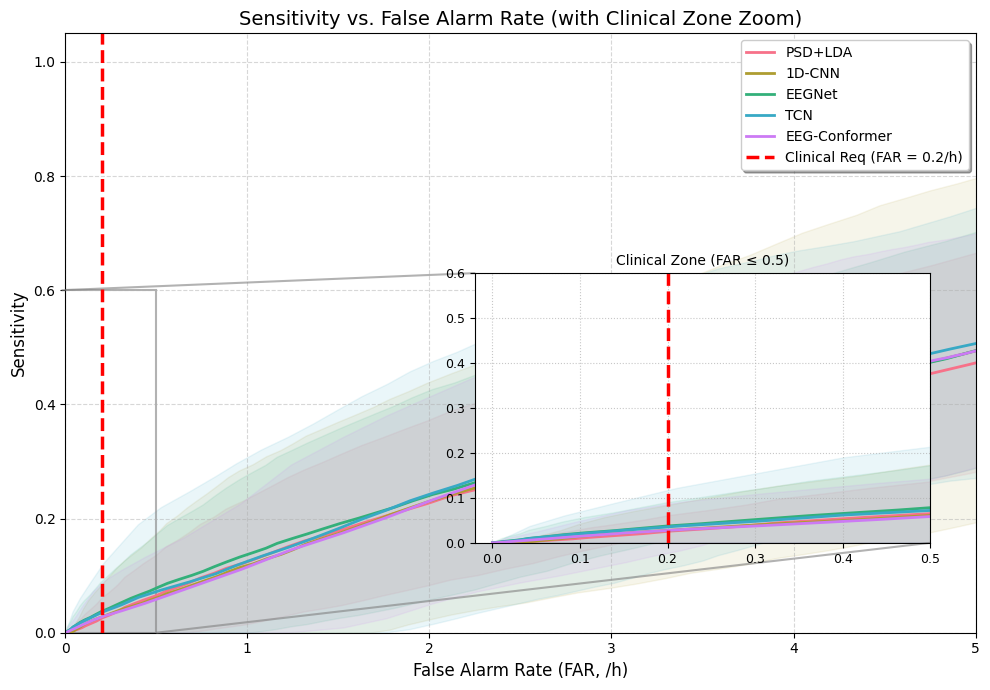

Figure 1 (FAR-Sensitivity with Inset) generated and saved.


In [14]:
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# 创建画布
fig, ax = plt.subplots(figsize=(10, 7))

# --- 核心改进：在主图的右下角开辟局部放大图 ---
# [x_left, y_bottom, width, height]
axins = ax.inset_axes([0.45, 0.15, 0.5, 0.45]) 

colors = sns.color_palette("husl", len(model_names))
clinical_threshold = 0.2

for i, mname in enumerate(model_names):
    # 直接提取你刚刚计算好的数据
    mean_far, mean_sen, std_far, std_sen = far_sen_data[mname]
    
    # 1. 绘制主图
    ax.plot(mean_far, mean_sen, label=mname, color=colors[i], lw=2)
    # 加上浅色阴影表示 1 倍标准差 (展示模型在不同 Seed 下的方差)
    ax.fill_between(mean_far, 
                    np.clip(mean_sen - std_sen, 0, 1), 
                    np.clip(mean_sen + std_sen, 0, 1), 
                    color=colors[i], alpha=0.1)
    
    # 2. 绘制放大图
    axins.plot(mean_far, mean_sen, color=colors[i], lw=2)
    axins.fill_between(mean_far, 
                       np.clip(mean_sen - std_sen, 0, 1), 
                       np.clip(mean_sen + std_sen, 0, 1), 
                       color=colors[i], alpha=0.1)

# --- 重点：添加临床红线 ---
ax.axvline(clinical_threshold, color='red', linestyle='--', lw=2.5, 
           label=f'Clinical Req (FAR = {clinical_threshold}/h)')
axins.axvline(clinical_threshold, color='red', linestyle='--', lw=2.5)

# --- 主图坐标轴设置 ---
ax.set_xlim(0, 5.0)   # 按照你原来的逻辑，画到 5/h
ax.set_ylim(0.0, 1.05)
ax.set_xlabel('False Alarm Rate (FAR, /h)', fontsize=12)
ax.set_ylabel('Sensitivity', fontsize=12)
ax.set_title('Sensitivity vs. False Alarm Rate (with Clinical Zone Zoom)', fontsize=14)
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.grid(True, linestyle='--', alpha=0.5)

# --- 放大图坐标轴设置 (强力聚焦) ---
axins.set_xlim(-0.02, 0.5)  # 只看 0 到 0.5/h 的范围
axins.set_ylim(0.0, 0.6)    # 根据这个区间内实际的最佳 Sensitivity (比如最高只有 0.4~0.6) 进行截断调整
axins.set_title('Clinical Zone (FAR ≤ 0.5)', fontsize=10)
axins.grid(True, linestyle=':', alpha=0.7)
axins.tick_params(axis='both', which='major', labelsize=9)

# 画出连接主图和放大图的灰色引导线
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="gray", lw=1.5, alpha=0.6)

plt.tight_layout()

# 保存高质量图表
fig.savefig(os.path.join(FIG_DIR, 'Figure_1_FAR_Sensitivity_Inset.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'Figure_1_FAR_Sensitivity_Inset.png'), dpi=300, bbox_inches='tight')

plt.show()
print('Figure 1 (FAR-Sensitivity with Inset) generated and saved.')

C:\Users\11217\AppData\Local\Temp\ipykernel_39164\2523538748.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


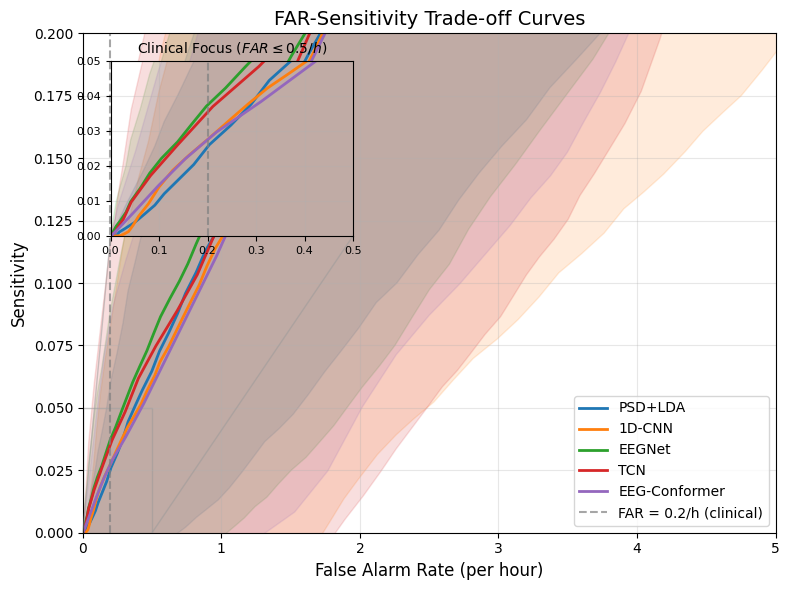


Sensitivity at FAR = 0.2/h:
  PSD+LDA             : 0.026
  1D-CNN              : 0.028
  EEGNet              : 0.037
  TCN                 : 0.037
  EEG-Conformer       : 0.030


In [15]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 1. 初始化主图
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 2. 初始化局部放大图 (Inset)
# loc='upper left' 放在左上角，通常这里的空间最宽裕。
# 如果与你的数据曲线重叠，可以改为 'center right' 或通过 bbox_to_anchor 微调。
axins = inset_axes(ax, width="35%", height="35%", loc='upper left', borderpad=2)

for idx, mname in enumerate(model_names):
    mean_far, mean_sen, std_far, std_sen = far_sen_data[mname]
    
    # 在主图上绘制
    ax.plot(mean_far, mean_sen, label=mname, color=colors[idx], linewidth=2)
    ax.fill_between(mean_far, mean_sen - std_sen, mean_sen + std_sen,
                    alpha=0.15, color=colors[idx])
    
    # 同步在放大图上绘制
    axins.plot(mean_far, mean_sen, color=colors[idx], linewidth=2)
    axins.fill_between(mean_far, mean_sen - std_sen, mean_sen + std_sen,
                       alpha=0.15, color=colors[idx])

# 3. 主图格式设置
ax.axvline(x=0.2, color='gray', linestyle='--', alpha=0.7, label='FAR = 0.2/h (clinical)')
ax.set_xlabel('False Alarm Rate (per hour)', fontsize=12)
ax.set_ylabel('Sensitivity', fontsize=12)
ax.set_title('FAR-Sensitivity Trade-off Curves', fontsize=14)
ax.set_xlim([0, 5])
ax.set_ylim([0, 0.20])
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# 4. 放大图 (Inset) 格式设置
axins.axvline(x=0.2, color='gray', linestyle='--', alpha=0.7)
axins.set_xlim(0, 0.5) # 重点放大 FAR 0 到 0.5 的区间
# 敏感度在 FAR=0.5 时通常不到 5%，设置 Y 轴上限为 0.05，让曲线间距拉开。
# 如果跑出来发现线超出了框，可以适当把 0.05 调大到 0.08。
axins.set_ylim(0, 0.05) 
axins.set_title(r'Clinical Focus ($FAR \leq 0.5/h$)', fontsize=10)
axins.tick_params(axis='both', which='major', labelsize=8)
axins.grid(True, alpha=0.3)

# 5. 绘制主图与放大图之间的连接指示线
# loc1 和 loc2 控制连接线的锚点角 (1=右上, 2=左上, 3=左下, 4=右下)
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.6", alpha=0.5)

plt.tight_layout()

# 保存高质量图表
fig.savefig(os.path.join(FIG_DIR, 'far_sensitivity_curves.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'far_sensitivity_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

# 打印在临床阈值处的具体数值
print('\nSensitivity at FAR = 0.2/h:')
for mname in model_names:
    mean_far, mean_sen, _, _ = far_sen_data[mname]
    # Find closest FAR to 0.2
    idx_02 = np.argmin(np.abs(mean_far - 0.2))
    print(f'  {mname:20s}: {mean_sen[idx_02]:.3f}')

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 1. 初始化主图
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 2. 初始化局部放大图 (Inset)
axins = inset_axes(ax, width="35%", height="35%", loc='upper left', borderpad=2)

for idx, mname in enumerate(model_names):
    mean_far, mean_sen, std_far, std_sen = far_sen_data[mname]
    
    # 在主图上绘制
    ax.plot(mean_far, mean_sen, label=mname, color=colors[idx], linewidth=2)
    ax.fill_between(mean_far, mean_sen - std_sen, mean_sen + std_sen,
                    alpha=0.15, color=colors[idx])
    
    # 同步在放大图上绘制
    axins.plot(mean_far, mean_sen, color=colors[idx], linewidth=2)
    axins.fill_between(mean_far, mean_sen - std_sen, mean_sen + std_sen,
                       alpha=0.15, color=colors[idx])

# 3. 主图格式设置
ax.axvline(x=0.2, color='gray', linestyle='--', alpha=0.7, label='FAR = 0.2/h (clinical)')
ax.set_xlabel('False Alarm Rate (per hour)', fontsize=12)
ax.set_ylabel('Sensitivity', fontsize=12)
ax.set_title('FAR-Sensitivity Trade-off Curves', fontsize=14)
ax.set_xlim([0, 5])
ax.set_ylim([0, 1.0])
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# 4. 放大图 (Inset) 格式设置
axins.axvline(x=0.2, color='gray', linestyle='--', alpha=0.7)
axins.set_xlim(0, 0.5)
axins.set_ylim(0, 0.15)  # 临床区间内灵敏度实际在 3-10% 左右，留余量到 15%
axins.set_title(r'Clinical Focus ($FAR \leq 0.5/h$)', fontsize=10)
axins.tick_params(axis='both', which='major', labelsize=8)
axins.grid(True, alpha=0.3)

# 5. 绘制主图与放大图之间的连接指示线
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.6", alpha=0.5)

plt.tight_layout()

# 保存高质量图表
fig.savefig(os.path.join(FIG_DIR, 'far_sensitivity_curves.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'far_sensitivity_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

# 打印在临床阈值处的具体数值
print('\nSensitivity at FAR = 0.2/h:')
for mname in model_names:
    mean_far, mean_sen, _, _ = far_sen_data[mname]
    idx_02 = np.argmin(np.abs(mean_far - 0.2))
    print(f'  {mname:20s}: {mean_sen[idx_02]:.3f}')

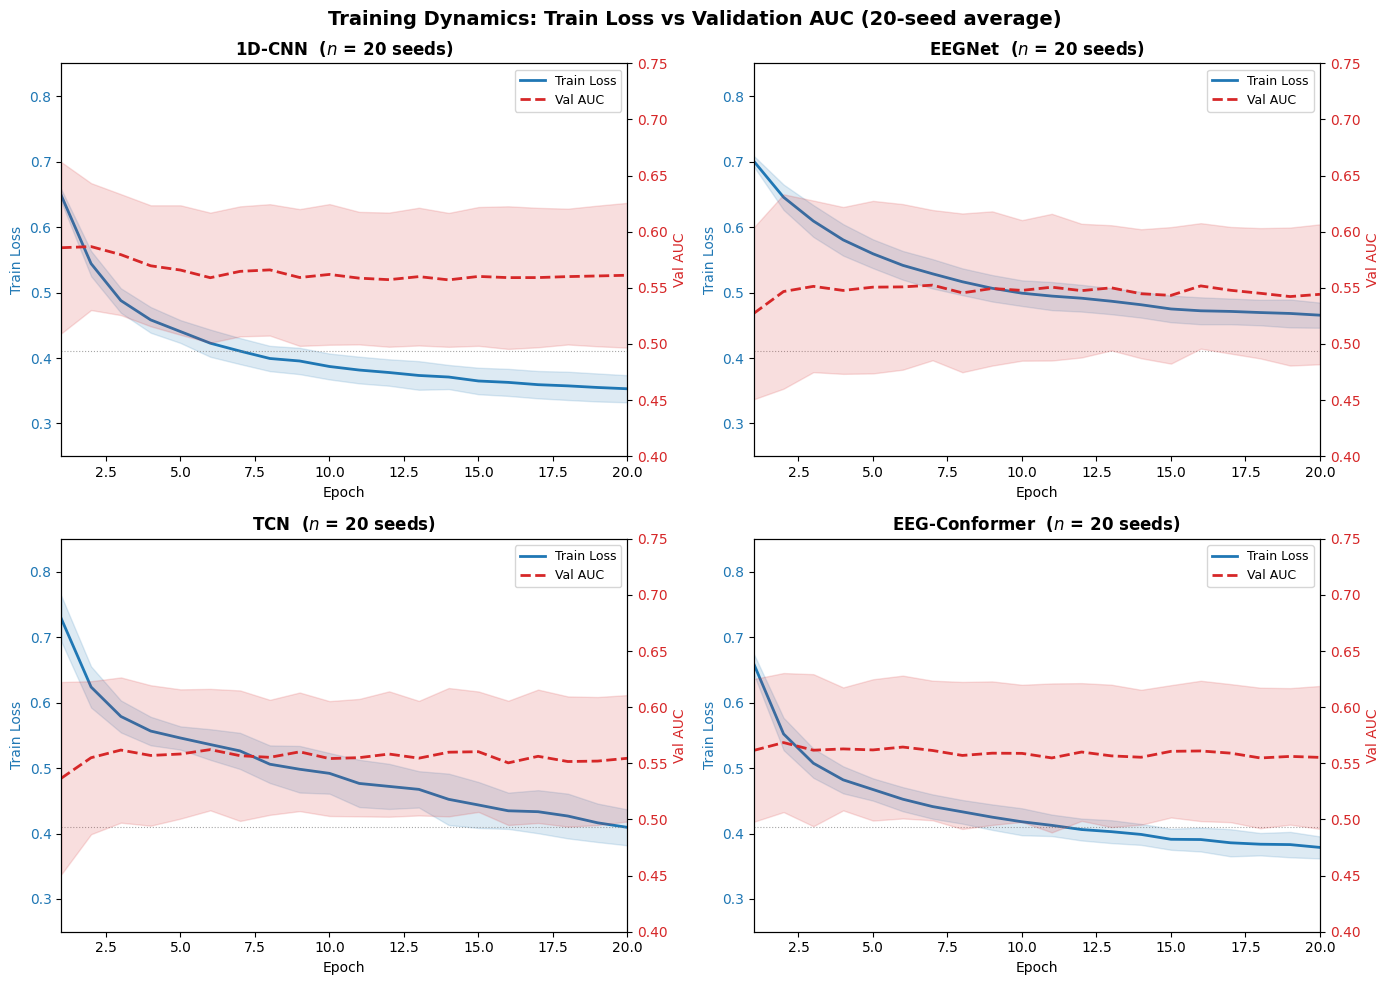

Saved: D:\seizure_results\figures\training_dynamics.png
Seeds parsed: {'1D-CNN': 20, 'EEGNet': 20, 'TCN': 20, 'EEG-Conformer': 20}


In [16]:
import re as _re

_DL_MODELS = [m for m in model_names if m != 'PSD+LDA']
TRAIN_NOTEBOOKS = {
    '1D-CNN':        r'D:\Code\train_1dcnn.ipynb',
    'EEGNet':        r'D:\Code\train_eegnet.ipynb',
    'TCN':           r'D:\Code\train_tcn.ipynb',
    'EEG-Conformer': r'D:\Code\train_eeg_conformer.ipynb',
}
PLOT_EPOCHS = 20

_EP_PAT  = _re.compile(r'Epoch\s+\d+\s*\|\s*loss\s+([\d.]+)\s*\|\s*val AUC\s+([\d.]+)')
_SEP_PAT = _re.compile(r'^\s*={20,}\s*$')

def _parse_dynamics(nb_path):
    """Return list of (losses, val_aucs) per seed from notebook stdout."""
    with open(nb_path) as _fh:
        _nb = json.load(_fh)
    lines = []
    for cell in _nb['cells']:
        if cell['cell_type'] == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'stream':
                    lines.extend(out.get('text', []))
    seeds, cur_l, cur_a = [], [], []
    for ln in lines:
        if _SEP_PAT.match(ln):
            if cur_l:
                seeds.append((cur_l, cur_a))
                cur_l, cur_a = [], []
            continue
        m = _EP_PAT.search(ln)
        if m:
            cur_l.append(float(m.group(1)))
            cur_a.append(float(m.group(2)))
    if cur_l:
        seeds.append((cur_l, cur_a))
    return seeds

# Parse all notebooks once; reused by both the plot loop and the summary print
_all_dynamics = {mname: _parse_dynamics(TRAIN_NOTEBOOKS[mname]) for mname in _DL_MODELS}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Dynamics: Train Loss vs Validation AUC (20-seed average)',
             fontsize=14, fontweight='bold', y=0.98)

_CLOSS = '#1f77b4'
_CAUC  = '#d62728'
_EPOCH_X = np.arange(1, PLOT_EPOCHS + 1)

for ax, mname in zip(axes.flat, _DL_MODELS):
    data = _all_dynamics[mname]
    n_seeds = len(data)

    loss_mat = np.full((n_seeds, PLOT_EPOCHS), np.nan)
    auc_mat  = np.full((n_seeds, PLOT_EPOCHS), np.nan)
    for i, (ls, aus) in enumerate(data):
        n = min(len(ls), PLOT_EPOCHS)
        loss_mat[i, :n] = ls[:n]
        auc_mat[i,  :n] = aus[:n]

    mean_loss = np.nanmean(loss_mat, axis=0)
    std_loss  = np.nanstd(loss_mat,  axis=0)
    mean_auc  = np.nanmean(auc_mat,  axis=0)
    std_auc   = np.nanstd(auc_mat,   axis=0)

    ax2 = ax.twinx()

    ax.plot(_EPOCH_X, mean_loss, color=_CLOSS, linewidth=2, label='Train Loss')
    ax.fill_between(_EPOCH_X, mean_loss - std_loss, mean_loss + std_loss,
                    color=_CLOSS, alpha=0.15)
    ax.axhline(y=0.41, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)

    ax2.plot(_EPOCH_X, mean_auc, color=_CAUC, linewidth=2, linestyle='--', label='Val AUC')
    ax2.fill_between(_EPOCH_X, mean_auc - std_auc, mean_auc + std_auc,
                     color=_CAUC, alpha=0.15)

    ax.set_title(f'{mname}  ($n$ = {n_seeds} seeds)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss', color=_CLOSS)
    ax2.set_ylabel('Val AUC',   color=_CAUC)
    ax.tick_params(axis='y', labelcolor=_CLOSS)
    ax2.tick_params(axis='y', labelcolor=_CAUC)
    ax.set_xlim(1, PLOT_EPOCHS)
    ax.set_ylim(0.25, 0.85)
    ax2.set_ylim(0.40, 0.75)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9)

plt.tight_layout()
_dyn_path = os.path.join(FIG_DIR, 'training_dynamics.png')
plt.savefig(_dyn_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_dyn_path}')
print(f'Seeds parsed: { {m: len(d) for m, d in _all_dynamics.items()} }')

## 6. Summary for LaTeX

In [17]:
# --- 重新计算汇总指标 ---
# 1. 构建热力图矩阵 (计算每个患者在每个模型上的平均 AUC)
all_patients = set()
for m in model_names:
    for seed_data in all_per_patient[m].values():
        all_patients.update(seed_data.keys())
all_patients = sorted(all_patients)

heatmap = np.full((len(all_patients), len(model_names)), np.nan)
for j, m in enumerate(model_names):
    for i, pt in enumerate(all_patients):
        vals = [all_per_patient[m][s].get(pt, np.nan) for s in SEEDS]
        vals = [v for v in vals if not np.isnan(v)]
        if vals:
            heatmap[i, j] = np.mean(vals)

# 2. 计算 Hard 和 Easy 患者数量
# 所有模型平均 AUC <= 0.55 的患者 (难以预测的)
n_hard = int(np.sum(np.nanmean(heatmap, axis=1) <= 0.55))
# 至少有一个模型能跑出 > 0.70 的患者 (容易预测的)
n_easy = int(np.sum(np.nanmax(heatmap, axis=1) > 0.70))

print("Summary metrics re-calculated successfully.")

Summary metrics re-calculated successfully.


In [18]:
print('=' * 60)
print('NUMBERS TO FILL IN LATEX')
print('=' * 60)

print('\n-- Parameter Counts --')
for name, n in param_counts.items():
    print(f'  {name:20s}: {n:,}')

print('\n-- Per-Patient Summary --')
print(f'  Hard patients (mean AUC <= 0.55): {n_hard}')
print(f'  Easy patients (AUC > 0.70 on >= 1 model): {n_easy}')

print('\n-- FAR-Sensitivity at clinical threshold --')
for mname in model_names:
    mean_far, mean_sen, _, _ = far_sen_data[mname]
    idx_02 = np.argmin(np.abs(mean_far - 0.2))
    print(f'  {mname:20s}: sensitivity = {mean_sen[idx_02]:.3f} at FAR ~{mean_far[idx_02]:.2f}/h')

print('\nDone! Copy these numbers into the manuscript.')
print(f'Figures saved to: {FIG_DIR}')

NUMBERS TO FILL IN LATEX

-- Parameter Counts --
  1D-CNN              : 520,322
  EEGNet              : 7,002
  TCN                 : 245,122
  EEG-Conformer       : 852,746

-- Per-Patient Summary --
  Hard patients (mean AUC <= 0.55): 16
  Easy patients (AUC > 0.70 on >= 1 model): 3

-- FAR-Sensitivity at clinical threshold --
  PSD+LDA             : sensitivity = 0.026 at FAR ~0.20/h
  1D-CNN              : sensitivity = 0.028 at FAR ~0.20/h
  EEGNet              : sensitivity = 0.037 at FAR ~0.20/h
  TCN                 : sensitivity = 0.037 at FAR ~0.21/h
  EEG-Conformer       : sensitivity = 0.030 at FAR ~0.22/h

Done! Copy these numbers into the manuscript.
Figures saved to: D:\seizure_results\figures
